In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

import pickle

In [5]:
df = pd.read_csv("beer-servings.csv")

df.head()

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    193 non-null    int64  
 1   country                       193 non-null    object 
 2   beer_servings                 185 non-null    float64
 3   spirit_servings               185 non-null    float64
 4   wine_servings                 187 non-null    float64
 5   total_litres_of_pure_alcohol  192 non-null    float64
 6   continent                     193 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 10.7+ KB


In [7]:
df = df.drop('Unnamed: 0', axis=1)

In [8]:
df = df.dropna()

In [9]:
print(df.columns)

Index(['country', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')


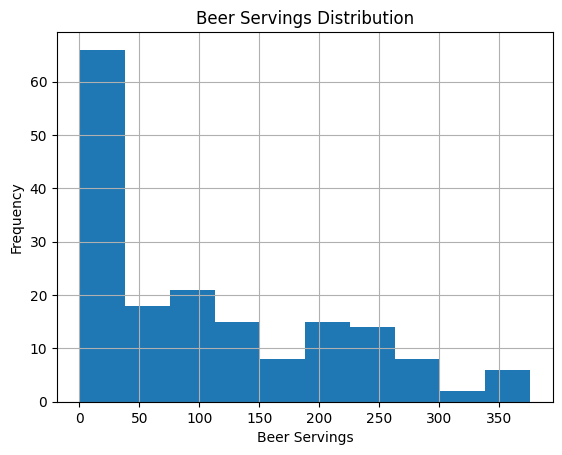

In [10]:
plt.figure()
df['beer_servings'].hist()

plt.title("Beer Servings Distribution")
plt.xlabel("Beer Servings")
plt.ylabel("Frequency")

plt.show()

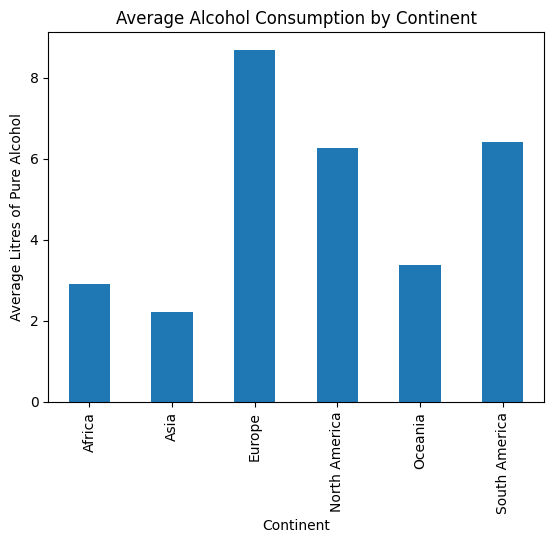

In [11]:
plt.figure()

df.groupby('continent')['total_litres_of_pure_alcohol'].mean().plot(kind='bar')

plt.title("Average Alcohol Consumption by Continent")
plt.xlabel("Continent")
plt.ylabel("Average Litres of Pure Alcohol")

plt.show()

In [12]:
df = pd.get_dummies(df, columns=['continent'], drop_first=True)

In [13]:
df = df.drop('country', axis=1)

In [14]:
X = df.drop('total_litres_of_pure_alcohol', axis=1)

y = df['total_litres_of_pure_alcohol']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression R2 Score:", r2_score(y_test, pred_lr))

Linear Regression R2 Score: 0.8359752757914022


In [17]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, pred_rf))

Random Forest R2 Score: 0.8213602944083399


In [18]:
params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    params,
    cv=5
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 200}


In [19]:
pred_best = best_model.predict(X_test)

print("Best Model R2 Score:", r2_score(y_test, pred_best))

Best Model R2 Score: 0.816331023112149


In [20]:
import pickle
pickle.dump(best_model, open("model.pkl","wb"))